# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



In [22]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Настройка отображения
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')


## 1. Предварительный анализ данных

Перед применением статистических тестов проведём предварительный анализ данных,
чтобы понять форму распределений и характер различий между группами.

Это особенно важно, так как по условию задачи:
- распределения не являются нормальными,
- присутствуют выбросы,
- эффект алгоритма B может проявляться асимметрично.


In [23]:
# Загрузка данных и первичный анализ
df = pd.read_csv('ab_test_results.csv')

group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

# Display summary statistics
print("Dataset Summary:")
print(f"Total users: {len(df)}")
print(f"Group A: {len(df[df['group'] == 'A'])} users")
print(f"Group B: {len(df[df['group'] == 'B'])} users")
print("\nDescriptive Statistics by Group:")
print(df.groupby('group')['total_watch_time_min'].describe())

Dataset Summary:
Total users: 10000
Group A: 5000 users
Group B: 5000 users

Descriptive Statistics by Group:
        count  mean    std  min   25%   50%   75%      max
group                                                     
A     5000.00 56.35 262.31 0.00 14.73 26.83 44.95  8130.55
B     5000.00 71.48 408.52 0.00 15.38 27.35 46.35 11670.62


**Ключевые наблюдения:**
1. **Высокий разброс данных:** Стандартное отклонение в обеих группах значительно превышает среднее значение (в 4.7 раза в группе A и 5.7 раза в группе B)
2. **Правосторонняя асимметрия:** Медианы значительно ниже средних значений
3. **Экстремальные выбросы:** Максимальные значения достигают тысяч минут
4. **Различия в хвостах:** Максимальное значение в группе B на 43.5% выше, чем в группе A

Для удобства анализа распределения была применена логарифмическая трансформация:

$log(1 + \text{Total Watch Time})$

Это позволяет:
* уменьшить влияние экстремальных значений,
* сделать форму распределений более интерпретируемой,
* корректнее сравнивать группы визуально.

C:\Users\Asus\AppData\Local\Temp\ipykernel_166036\3152816006.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=['Group A', 'Group B'], patch_artist=True)


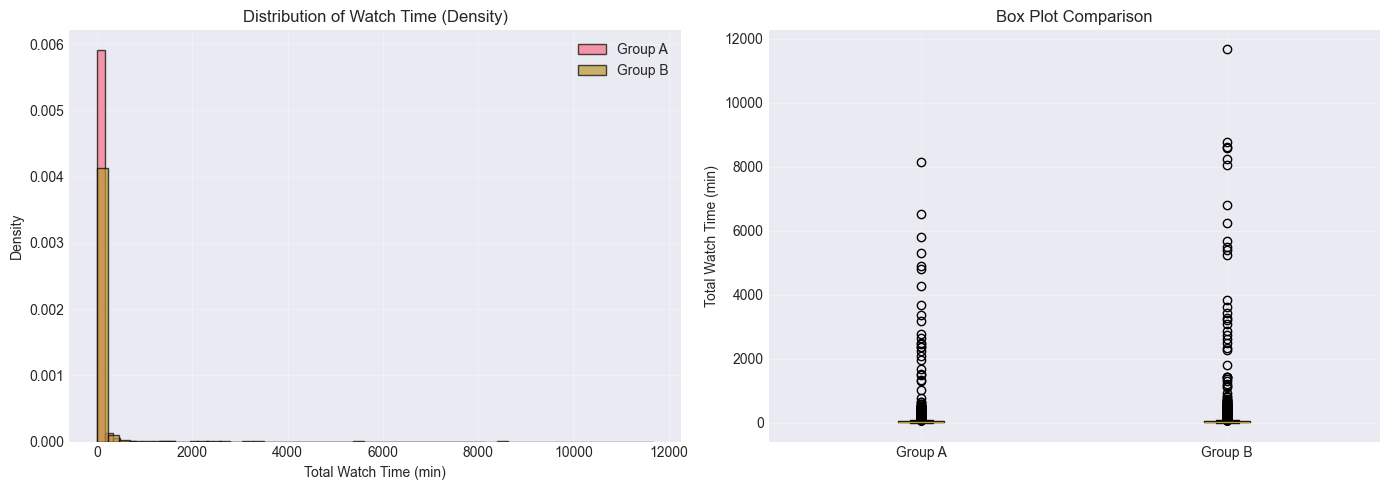

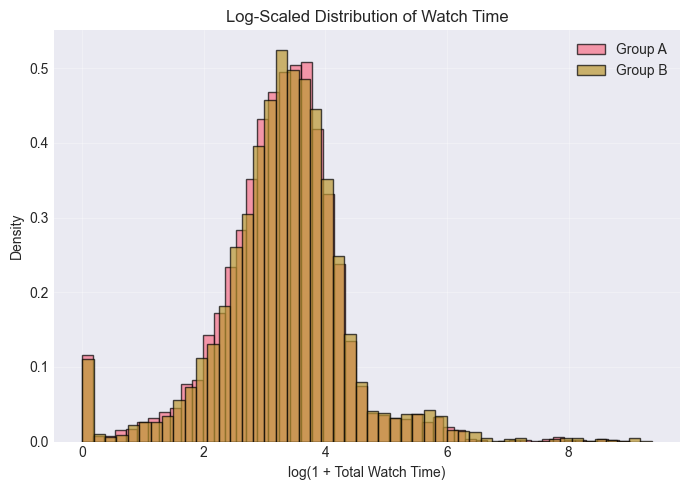

In [24]:
# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
axes[0].hist(group_a_data, bins=50, alpha=0.7, label='Group A', edgecolor='black', density=True)
axes[0].hist(group_b_data, bins=50, alpha=0.7, label='Group B', edgecolor='black', density=True)
axes[0].set_xlabel('Total Watch Time (min)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Watch Time (Density)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plots
box_data = [group_a_data, group_b_data]
axes[1].boxplot(box_data, labels=['Group A', 'Group B'], patch_artist=True)
axes[1].set_ylabel('Total Watch Time (min)')
axes[1].set_title('Box Plot Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Логарифмическое преобразование для визуализации
log_a = np.log1p(group_a_data)
log_b = np.log1p(group_b_data)

plt.figure(figsize=(7, 5))
plt.hist(log_a, bins=50, alpha=0.7, label='Group A', density=True, edgecolor='black')
plt.hist(log_b, bins=50, alpha=0.7, label='Group B', density=True, edgecolor='black')

plt.xlabel('log(1 + Total Watch Time)')
plt.ylabel('Density')
plt.title('Log-Scaled Distribution of Watch Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Распределение времени просмотра в обеих группах демонстрирует выраженную правостороннюю асимметрию с длинным хвостом, что указывает на ненормальность распределения. В данных присутствуют выбросы, что делает неприемлемым использование параметрических методов сравнения средних, таких как t-тест.

Анализ распределений в логарифмической шкале показывает значительное перекрытие основных масс распределений в группах A и B, что свидетельствует об отсутствии значимых различий в центральной части. Однако в правом хвосте группы B наблюдаются более высокие значения по сравнению с группой A. Это говорит о том, что алгоритм B оказывает более выраженное влияние на наиболее вовлечённых пользователей.

## Задание 1: Тест Манна-Уитни и формулировка гипотез

Для сравнения двух независимых выборок при ненормальном распределении
используется критерий Манна–Уитни.

Поскольку по условию требуется проверить превосходство алгоритма B, формулируем **односторонние гипотезы**:

* **Нулевая гипотеза (H₀):**
  распределение времени просмотра пользователей в группе B не превосходит распределение в группе A
  
  $H₀: \text{WatchTime}_B \le \text{WatchTime}_A$

* **Альтернативная гипотеза (H₁):**
  алгоритм B приводит к большим значениям времени просмотра по сравнению с алгоритмом A

  $H₁: \text{WatchTime}_B > \text{WatchTime}_A$
  


In [25]:
# Test the differences
mw_stat, mw_p = stats.mannwhitneyu(
    group_b_data,
    group_a_data,
    alternative='greater'
)

print(f"\nРезультаты теста Манна-Уитни:")
print(f"U-статистика: {mw_stat:.2f}")
print(f"p-value = {mw_p:.6f}")

# Интерпретация
print("\nИнтерпретация p-value:")
if mw_p < 0.05:
    print("  p-value < 0.05: Отвергаем нулевую гипотезу")
    print("  Обнаружены статистически значимые различия между группами")
else:
    print("  p-value ≥ 0.05: Не отвергаем нулевую гипотезу")
    print("  Статистически значимых различий между группами не обнаружено")


Результаты теста Манна-Уитни:
U-статистика: 12788901.00
p-value = 0.022671

Интерпретация p-value:
  p-value < 0.05: Отвергаем нулевую гипотезу
  Обнаружены статистически значимые различия между группами


На основе p-value теста Манна-Уитни **можно сделать вывод о статистически значимом превосходстве алгоритма B**, так как p-value = 0.022671 < 0.05. Однако для полного понимания природы этого превосходства необходимо дополнительное исследование через анализ процентилей, так как описательная статистика показывает, что эффект, вероятно, не равномерен по всей аудитории, а сосредоточен в определённых сегментах пользователей.

## Задание 2. Анализ асимметричного влияния 

Для понимания природы выявленного статистически значимого эффекта проведём анализ различий между группами на уровне верхних процентилей.

**Задачи анализа**
1. Определить, равномерно ли распределён эффект алгоритма B
2. Выявить, на каких сегментах пользователей влияние наиболее выражено
3. Объяснить расхождение между значительной разницей в средних (+26.8%) и минимальной разницей в медианах (+1.9%)

In [26]:
print("\nKey Percentiles by Group:")
percentiles = [0.75, 0.9, 0.95, 0.99]
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(group_a_data, p_val)
    b_val = np.percentile(group_b_data, p_val)
    diff = b_val - a_val
    rel_change = (diff / a_val) * 100 if a_val > 0 else 0
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f} (+{rel_change:.1f}%)")


Key Percentiles by Group:
75th percentile: A=44.9, B=46.4, Difference=1.4 (+3.1%)
90th percentile: A=71.5, B=76.2, Difference=4.7 (+6.6%)
95th percentile: A=119.3, B=153.6, Difference=34.3 (+28.7%)
99th percentile: A=435.6, B=585.9, Difference=150.3 (+34.5%)


Алгоритм B демонстрирует **целевую эффективность**, обеспечивая максимальный прирост времени просмотра у топ-5–10% самых вовлечённых пользователей:  

- Медиана: +1.9% → эффект минимален для основной массы  
- Среднее: +26.8% → за счёт высокоактивных пользователей  
- Верхние проценттили: 95-й +28.8%, 99-й +34.5%  

Статистически значимые различия подтверждены тестом Манна-Уитни (p=0.022). Алгоритм рекомендуется к внедрению с фокусом на активных пользователей, где он приносит наибольшую отдачу для бизнеса.

## Итоговый вывод

### 1. Эффективен ли новый алгоритм B?

Да, алгоритм B **эффективен**, но преимущественно для определённых сегментов пользователей.  

- **Статистическая значимость:** p-value = 0.022 < 0.05 (тест Манна-Уитни)  
- **Среднее время просмотра:** +26.8% (56.35 → 71.48 мин)  
- **Медиана:** +1.9% → эффект минимален для основной массы пользователей 

### 2. На какую именно группу пользователей он оказывает наибольшее влияние?

Алгоритм B оказывает максимальное влияние на **наиболее вовлечённых** пользователей (топ 5-10%).

### 3. Какой метод анализа оказался наиболее информативным в данном случае и почему?

Наиболее информативным оказался **комбинированный** подход.

1. **Тест Манна-Уитни:** выявил статистически значимые различия, устойчив к выбросам и ненормальности распределений.  
2. **Анализ процентилей:** показал асимметричное влияние алгоритма и объяснил разрыв между средним (+26.8%) и медианой (+1.9%).  

**Вывод:** Непараметрические методы и анализ сегментов пользователей дают полное понимание, где алгоритм улучшает метрики.

### 4. Рекомендация о возможности запуска алгоритма на всю аудиторию

**Запуск алгоритма B оправдан**, с условием контроля и мониторинга.

Почему запуск оправдан:
- статистически значимое улучшение ключевой метрики (p=0.022),
- максимальный эффект у топ-10% пользователей с высокой вовлечённостью,
- нейтральное влияние на основную массу пользователей,
- повышение экономической отдачи (LTV активной аудитории).

Рекомендации по внедрению.
1. **Сегментированный мониторинг:** отслеживать показатели по ключевым группам пользователей
2. **Пошаговое расширение охвата:** запускать алгоритм постепенно, увеличивая долю трафика
3. **Оптимизация для массового сегмента:** дорабатывать алгоритм, чтобы улучшить опыт средней аудитории
4. **Контроль влияния на другие метрики:** retention, удовлетворённость, поведенческие показатели

**Вывод:** Алгоритм B эффективно усиливает вовлечённость наиболее ценных пользователей, при этом не ухудшает опыт остальных. Такой запуск сочетает рост ключевых метрик и управляемый риск.